# Cifar 10 luokitteluprojekti FCN

In [7]:
from tensorflow.keras.datasets import cifar10
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import keras
from keras import layers
from keras.layers import Input, Dense, Flatten
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

## Retrieving the data and prepairing it
The targets are one-hot encoded into vectors as this will be later usefull with the softmax function. The features are normalized as without it, it wasn't able to learn anything.

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_test, x_val, y_test, y_val = train_test_split(
    x_test, y_test,
    test_size=0.5
)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)
y_val = keras.utils.to_categorical(y_val, 10)

mean = np.mean(x_train, axis=(0,1,2), keepdims=True)
std = np.std(x_train, axis=(0,1,2), keepdims=True)
x_train = (x_train-mean)/std
x_test = (x_test-mean)/std
x_val = (x_val-mean)/std

## Adding the layers and neurons
Each hidden layer has 512 neurons and there are 3 hidden layers. There is also an aggressive amount of dropout added to help with overfitting. ReLU is used to add non-linearity.

In [3]:
model = keras.models.Sequential([
    Input(shape=(32,32,3)),
    Flatten(),
    
    Dense(512),
    BatchNormalization(),
    keras.layers.Activation("relu"),
    Dropout(0.5),
    
    Dense(512),
    BatchNormalization(),
    keras.layers.Activation("relu"),
    Dropout(0.5),
    
    Dense(512),
    BatchNormalization(),
    keras.layers.Activation("relu"),
    Dropout(0.5),
    
    Dense(10, activation="softmax")
])

## Compiling and adding the appropriate callbacks
The optimizer uses rmsprop to update weights and categorical crossentropy to determine the cost.

The learning rate scheduler reduces the learning rate by 0.5, if the validation loss doesn't improve for 3 epochs, while making sure it never goes below 0.00005. This helps if the model learning is stuck.

The early stop makes it so that if the model fails to improve for 8 epochs, it stops trying and returns to previous best parameters.

In [4]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

## Fitting
Fitting with 200 epochs and also measuring the time.

In [5]:
start = time.time()

history=model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[lr_scheduler, early_stop]
)

end = time.time()
print(f"Training took {end - start:.2f} seconds")

Epoch 1/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.3106 - loss: 1.9951 - val_accuracy: 0.4202 - val_loss: 1.6154 - learning_rate: 0.0010
Epoch 2/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.3954 - loss: 1.6900 - val_accuracy: 0.4670 - val_loss: 1.5143 - learning_rate: 0.0010
Epoch 3/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4298 - loss: 1.6024 - val_accuracy: 0.4720 - val_loss: 1.4822 - learning_rate: 0.0010
Epoch 4/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.4472 - loss: 1.5601 - val_accuracy: 0.4956 - val_loss: 1.4117 - learning_rate: 0.0010
Epoch 5/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4596 - loss: 1.5252 - val_accuracy: 0.4978 - val_loss: 1.4018 - learning_rate: 0.0010
Epoch 6/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4749 - loss: 1.4945 - val_accuracy: 0.5128 - val_loss: 1.3700 - learning_rate: 0.0010
Epoch 7/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4

Presenting the data visually

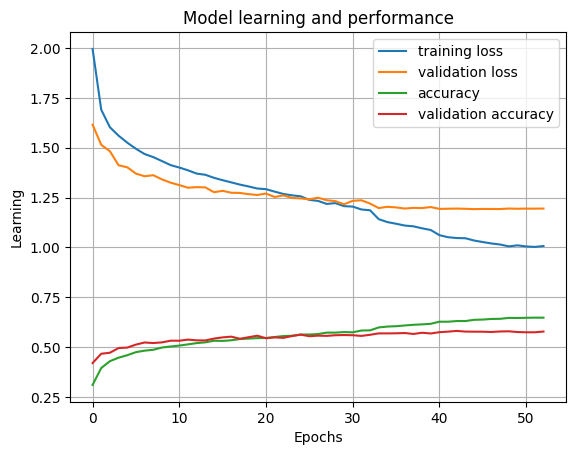

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


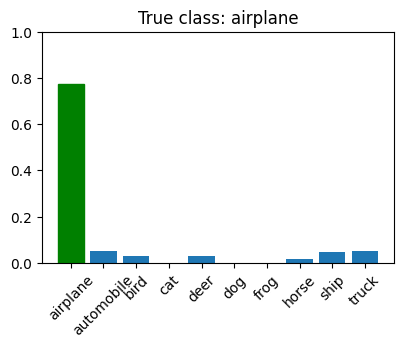

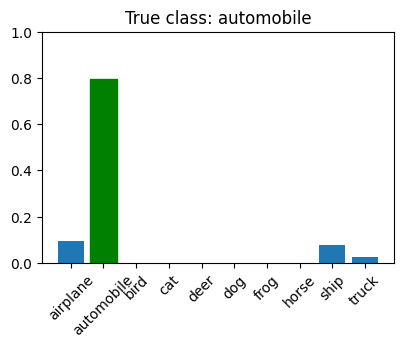

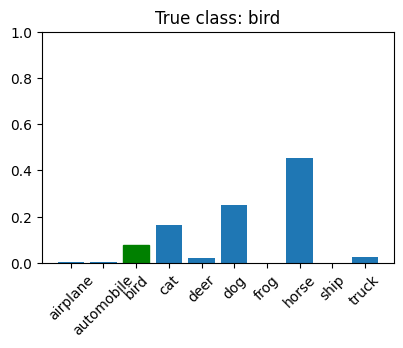

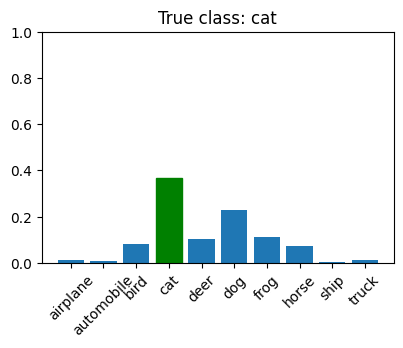

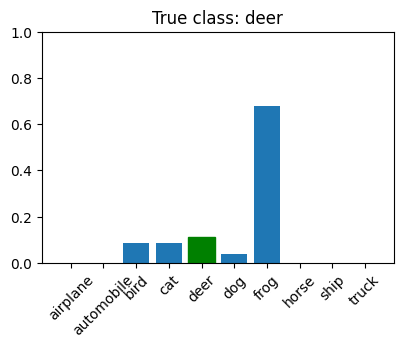

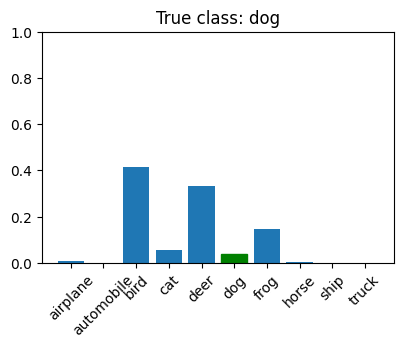

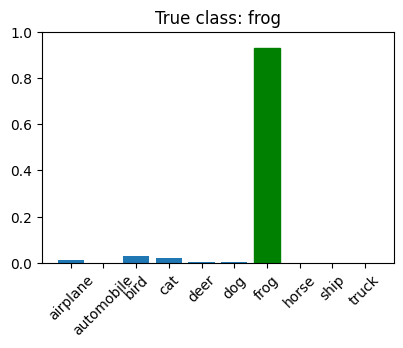

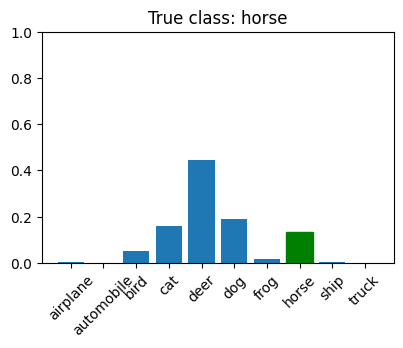

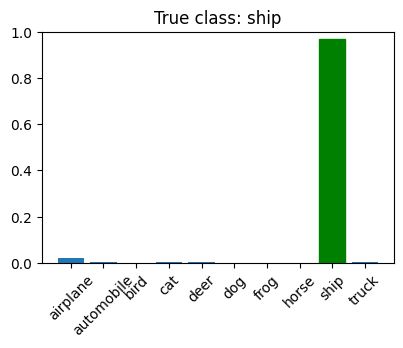

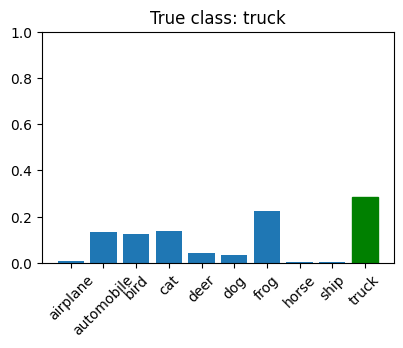

In [6]:
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Model learning and performance")
plt.xlabel('Epochs')
plt.ylabel('Learning')
plt.legend()
plt.grid()
plt.show()

class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

y_test_labels = np.argmax(y_test, axis=1)
indices = [np.where(y_test_labels == i)[0][0] for i in range(10)]
predictions = model.predict(x_test[indices])

for i, idx in enumerate(indices):
    plt.figure(figsize=(10,3))
    true = y_test_labels[idx]
    plt.subplot(1,2,2)
    bars = plt.bar(class_names, predictions[i])
    bars[true].set_color("green")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.title(f"True class: {class_names[true]}") 
    plt.show()